In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhagwantsingh01/bodmass-dataset/bodmas.npz
/kaggle/input/datasets/bhagwantsingh01/bodmass-dataset/bodmas_metadata.csv
/kaggle/input/datasets/bhagwantsingh01/bodmass-dataset/bodmas_malware_category.csv
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-09-22_2024-09-28_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-12-01_2024-12-07_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-11-10_2024-11-16_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-11-24_2024-11-30_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-12-08_2024-12-14_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-10-20_2024-10-26_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-10-27_2024-11-02_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-10-06_2024-10-12_Win64_test.jsonl
/kaggle/input/datasets/weiweip/ember2024/Win64_t

In [18]:
# ============================================================
#  EMBER2024 LOADER
# Converts JSONL -> small numeric parquet chunks
# Avoids holding raw JSON dictionaries in memory
# ============================================================

!pip install -q lightgbm scikit-learn pandas numpy scipy matplotlib tqdm joblib pyarrow

import os, glob, json, gc, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")

DATA_ROOT = "/kaggle/input/datasets/weiweip/ember2024/"
WORK_DIR = "/kaggle/working/ember_numeric_chunks"
os.makedirs(WORK_DIR, exist_ok=True)

RANDOM_STATE = 42

# Start safely
MAX_TOTAL_ROWS = 150000
ROWS_PER_FILE = 2500

LEAKAGE_COLS = {
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
}

LABEL_CANDIDATES = ["label", "y", "target", "malware", "is_malware"]

train_files = sorted(glob.glob(DATA_ROOT + "/**/*train*.jsonl", recursive=True))
test_files = sorted(glob.glob(DATA_ROOT + "/**/*test*.jsonl", recursive=True))
all_files = train_files + test_files

print("Train files:", len(train_files))
print("Test files:", len(test_files))
print("Total files:", len(all_files))

Train files: 52
Test files: 12
Total files: 64


In [19]:
# ============================================================
# FLATTEN ONLY NUMERIC VALUES
# ============================================================

def flatten_numeric_only(obj, parent_key="", sep="_"):
    out = {}

    for k, v in obj.items():
        key = f"{parent_key}{sep}{k}" if parent_key else str(k)

        if isinstance(v, dict):
            out.update(flatten_numeric_only(v, key, sep=sep))

        elif isinstance(v, list):
            for i, item in enumerate(v):
                if isinstance(item, (int, float, bool, np.integer, np.floating)):
                    out[f"{key}_{i}"] = item

        else:
            if isinstance(v, (int, float, bool, np.integer, np.floating)):
                out[key] = v

    return out


def detect_label(row):
    for c in LABEL_CANDIDATES:
        if c in row:
            return c
    return None

In [20]:
# ============================================================
# STAGE 1: STREAM JSONL INTO NUMERIC PARQUET CHUNKS
# ============================================================

def convert_jsonl_to_numeric_chunks(
    files,
    output_dir,
    max_total_rows=150000,
    rows_per_file=2500,
    seed=42
):
    random.seed(seed)
    total_saved = 0
    label_col_global = None
    chunk_paths = []

    for file_id, fp in enumerate(tqdm(files)):
        selected_rows = []
        seen = 0

        with open(fp, "r", errors="ignore") as f:
            for line in f:
                seen += 1

                try:
                    obj = json.loads(line)
                    flat = flatten_numeric_only(obj)
                except Exception:
                    continue

                label_col = detect_label(flat)

                if label_col is None:
                    continue

                if label_col_global is None:
                    label_col_global = label_col

                if label_col_global not in flat:
                    continue

                # reservoir sample per file
                if len(selected_rows) < rows_per_file:
                    selected_rows.append(flat)
                else:
                    j = random.randint(0, seen - 1)
                    if j < rows_per_file:
                        selected_rows[j] = flat

        if len(selected_rows) == 0:
            continue

        df = pd.DataFrame(selected_rows)

        if label_col_global not in df.columns:
            del df, selected_rows
            gc.collect()
            continue

        df = df.dropna(subset=[label_col_global])
        df[label_col_global] = df[label_col_global].astype(np.int8)

        # remove leakage if present
        drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)

        # convert all non-label columns to float32
        for c in df.columns:
            if c == label_col_global:
                continue
            df[c] = pd.to_numeric(df[c], errors="coerce").astype(np.float32)

        df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

        chunk_path = os.path.join(output_dir, f"chunk_{file_id:03d}.parquet")
        df.to_parquet(chunk_path, index=False)

        chunk_paths.append(chunk_path)
        total_saved += len(df)

        del df, selected_rows
        gc.collect()

        if total_saved >= max_total_rows:
            break

    print("Total saved rows:", total_saved)
    print("Detected label:", label_col_global)
    print("Chunks:", len(chunk_paths))

    return chunk_paths, label_col_global


chunk_paths, label_col = convert_jsonl_to_numeric_chunks(
    all_files,
    WORK_DIR,
    max_total_rows=MAX_TOTAL_ROWS,
    rows_per_file=ROWS_PER_FILE,
    seed=RANDOM_STATE
)

 92%|█████████▏| 59/64 [32:33<02:45, 33.10s/it]   

Total saved rows: 150000
Detected label: label
Chunks: 60


In [21]:
# ============================================================
# STAGE 2: FIND COMMON FEATURE COLUMNS
# Keeps only columns present across all chunks
# ============================================================

common_cols = None

for p in tqdm(chunk_paths):
    cols = pd.read_parquet(p).columns.tolist()
    cols = set(cols)

    if common_cols is None:
        common_cols = cols
    else:
        common_cols = common_cols.intersection(cols)

common_cols = list(common_cols)

if label_col not in common_cols:
    common_cols.append(label_col)

feature_cols = sorted([c for c in common_cols if c != label_col])

print("Common features:", len(feature_cols))
print("Label:", label_col)

100%|██████████| 60/60 [00:22<00:00,  2.69it/s]

Common features: 797
Label: label


In [22]:
# ============================================================
# STAGE 3: LOAD ONLY COMMON NUMERIC COLUMNS
# This is much smaller than raw JSON
# ============================================================

frames = []

for p in tqdm(chunk_paths):
    df = pd.read_parquet(p, columns=feature_cols + [label_col])
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

del frames
gc.collect()

data = data.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

X = data[feature_cols].astype(np.float32)
y = data[label_col].astype(int).values

del data
gc.collect()

print("Final X shape:", X.shape)
print("Label distribution:")
print(pd.Series(y).value_counts())

100%|██████████| 60/60 [00:10<00:00,  5.90it/s]


Final X shape: (150000, 797)
Label distribution:
1    75214
0    74786
Name: count, dtype: int64


In [24]:
# ============================================================
# STAGE 4: TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts())

X_train: (127500, 797)
X_test: (22500, 797)

Train label distribution:
1    63932
0    63568
Name: count, dtype: int64

Test label distribution:
1    11282
0    11218
Name: count, dtype: int64


In [25]:
# ============================================================
# STAGE 5: FIX LIGHTGBM FEATURE NAME ERROR
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Save original names
# ------------------------------------------------------------

original_feature_names = X_train.columns.tolist()

# ------------------------------------------------------------
# Create safe LightGBM names
# ------------------------------------------------------------

safe_feature_names = [
    f"f_{i}" for i in range(len(original_feature_names))
]

# ------------------------------------------------------------
# Mapping table
# ------------------------------------------------------------

feature_name_mapping = pd.DataFrame({
    "safe_name": safe_feature_names,
    "original_name": original_feature_names
})

# ------------------------------------------------------------
# Rename columns
# ------------------------------------------------------------

X_train.columns = safe_feature_names
X_test.columns = safe_feature_names

print("Feature names cleaned.")
print("Total features:", len(safe_feature_names))

# ------------------------------------------------------------
# Save mapping
# ------------------------------------------------------------

OUTPUT_DIR = "/kaggle/working/maltrust_xai_q1_revision_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

feature_name_mapping.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_name_mapping.csv"
    ),
    index=False
)

print("Feature-name mapping saved.")

Feature names cleaned.
Total features: 797
Feature-name mapping saved.


In [26]:
# ============================================================
# STAGE 6: LIGHTGBM TRAINING
# ============================================================

base_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=48,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=2,
    random_state=RANDOM_STATE,
    force_col_wise=True,
    verbosity=-1
)

base_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

proba_clean = base_model.predict_proba(X_test)[:, 1]
pred_clean = (proba_clean >= 0.5).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

clean_results = pd.DataFrame([{
    "Experiment": "Clean random split",
    "Samples": len(X_train) + len(X_test),
    "Features": X_train.shape[1],
    "Accuracy": accuracy_score(y_test, pred_clean),
    "Precision": precision_score(y_test, pred_clean, zero_division=0),
    "Recall": recall_score(y_test, pred_clean, zero_division=0),
    "F1": f1_score(y_test, pred_clean, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, proba_clean)
}])

clean_results

,Experiment,Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Clean random split,150000,797,0.989644,0.994186,0.985109,0.989626,0.999318


In [27]:
# ============================================================
# TEMPORAL VALIDATION USING FILE-DATE ORDER
# Works when temporal columns are missing inside chunks
# Uses original JSONL filename dates
# ============================================================

import os, re, json, gc, random
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ------------------------------------------------------------
# Extract start date from EMBER filename
# Example: 2023-09-24_2023-09-30_Win64_train.jsonl
# ------------------------------------------------------------

def extract_start_date_from_filename(path):
    name = os.path.basename(path)
    match = re.search(r"(\d{4}-\d{2}-\d{2})", name)
    if match:
        return pd.to_datetime(match.group(1), errors="coerce")
    return pd.NaT


dated_files = []

for fp in all_files:
    dt = extract_start_date_from_filename(fp)
    if pd.notna(dt):
        dated_files.append((fp, dt))

dated_files = sorted(dated_files, key=lambda x: x[1])

print("Dated files found:", len(dated_files))
print("Oldest:", dated_files[0])
print("Newest:", dated_files[-1])

Dated files found: 64
Oldest: ('/kaggle/input/datasets/weiweip/ember2024/Win64_train/2023-09-24_2023-09-30_Win64_train.jsonl', Timestamp('2023-09-24 00:00:00'))
Newest: ('/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-12-08_2024-12-14_Win64_test.jsonl', Timestamp('2024-12-08 00:00:00'))


In [28]:
# ============================================================
# SPLIT FILES TEMPORALLY
# Older 70% files = train
# Newer 30% files = test
# ============================================================

split_idx = int(len(dated_files) * 0.70)

temporal_train_files = [x[0] for x in dated_files[:split_idx]]
temporal_test_files  = [x[0] for x in dated_files[split_idx:]]

print("Temporal train files:", len(temporal_train_files))
print("Temporal test files:", len(temporal_test_files))

print("Train date range:", dated_files[0][1], "to", dated_files[split_idx-1][1])
print("Test date range:", dated_files[split_idx][1], "to", dated_files[-1][1])

Temporal train files: 44
Temporal test files: 20
Train date range: 2023-09-24 00:00:00 to 2024-07-21 00:00:00
Test date range: 2024-07-28 00:00:00 to 2024-12-08 00:00:00


In [29]:
# ============================================================
# REBUILD FILE LISTS AFTER KERNEL RESTART
# ============================================================

import os
import glob

# ------------------------------------------------------------
# DATASET ROOT
# ------------------------------------------------------------

DATA_ROOT = "/kaggle/input/datasets/weiweip/ember2024/"

# ------------------------------------------------------------
# FIND TRAIN / TEST JSONL FILES
# ------------------------------------------------------------

train_files = sorted(
    glob.glob(DATA_ROOT + "/**/*train*.jsonl", recursive=True)
)

test_files = sorted(
    glob.glob(DATA_ROOT + "/**/*test*.jsonl", recursive=True)
)

all_files = train_files + test_files

print("Training files:", len(train_files))
print("Testing files:", len(test_files))
print("Total files:", len(all_files))

print("\nExample train file:")
print(train_files[:1])

print("\nExample test file:")
print(test_files[:1])

Training files: 52
Testing files: 12
Total files: 64

Example train file:
['/kaggle/input/datasets/weiweip/ember2024/Win64_train/2023-09-24_2023-09-30_Win64_train.jsonl']

Example test file:
['/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-09-22_2024-09-28_Win64_test.jsonl']


In [ ]:
# ============================================================
# RECREATE TEMPORAL FILE SPLIT
# ============================================================

import re
import pandas as pd

def extract_start_date_from_filename(path):
    name = os.path.basename(path)

    match = re.search(r"(\d{4}-\d{2}-\d{2})", name)

    if match:
        return pd.to_datetime(match.group(1), errors="coerce")

    return pd.NaT

dated_files = []

for fp in all_files:
    dt = extract_start_date_from_filename(fp)

    if pd.notna(dt):
        dated_files.append((fp, dt))

dated_files = sorted(dated_files, key=lambda x: x[1])

print("Total dated files:", len(dated_files))

print("\nOldest file:")
print(dated_files[0])

print("\nNewest file:")
print(dated_files[-1])

split_idx = int(len(dated_files) * 0.70)

temporal_train_files = [x[0] for x in dated_files[:split_idx]]
temporal_test_files  = [x[0] for x in dated_files[split_idx:]]

print("\nTemporal train files:", len(temporal_train_files))
print("Temporal test files:", len(temporal_test_files))

print("\nTrain date range:")
print(dated_files[0][1], "to", dated_files[split_idx - 1][1])

print("\nTest date range:")
print(dated_files[split_idx][1], "to", dated_files[-1][1])

In [30]:
# ============================================================
# COMPLETE TEMPORAL SETUP + CHUNK GENERATION CELL
# Fixes: temporal_train_files is not defined
# ============================================================

import os
import re
import glob
import json
import gc
import random
import pandas as pd
import numpy as np
from tqdm import tqdm

# ------------------------------------------------------------
# Basic config
# ------------------------------------------------------------

DATA_ROOT = "/kaggle/input/datasets/weiweip/ember2024/"
RANDOM_STATE = 42

TEMP_ROWS_PER_FILE = 500   # safe first run

TEMP_WORK_DIR = "/kaggle/working/temporal_chunks"
TEMP_TRAIN_DIR = os.path.join(TEMP_WORK_DIR, "train")
TEMP_TEST_DIR = os.path.join(TEMP_WORK_DIR, "test")

os.makedirs(TEMP_TRAIN_DIR, exist_ok=True)
os.makedirs(TEMP_TEST_DIR, exist_ok=True)

LEAKAGE_COLS = {
    "first_submission_date",
    "last_analysis_date",
    "week_id",
    "detection_ratio_numeric",
    "authenticode_latest_signing_time",
    "authenticode_signing_time_diff"
}

LABEL_CANDIDATES = ["label", "y", "target", "malware", "is_malware"]

# ------------------------------------------------------------
# Rebuild file lists
# ------------------------------------------------------------

train_files = sorted(glob.glob(DATA_ROOT + "/**/*train*.jsonl", recursive=True))
test_files = sorted(glob.glob(DATA_ROOT + "/**/*test*.jsonl", recursive=True))
all_files = train_files + test_files

print("Training files:", len(train_files))
print("Testing files:", len(test_files))
print("Total files:", len(all_files))

if len(all_files) == 0:
    raise FileNotFoundError("No JSONL files found. Check DATA_ROOT.")

# ------------------------------------------------------------
# Date extraction from filenames
# ------------------------------------------------------------

def extract_start_date_from_filename(path):
    name = os.path.basename(path)
    match = re.search(r"(\d{4}-\d{2}-\d{2})", name)
    if match:
        return pd.to_datetime(match.group(1), errors="coerce")
    return pd.NaT

dated_files = []

for fp in all_files:
    dt = extract_start_date_from_filename(fp)
    if pd.notna(dt):
        dated_files.append((fp, dt))

dated_files = sorted(dated_files, key=lambda x: x[1])

print("Total dated files:", len(dated_files))

if len(dated_files) == 0:
    raise ValueError("No dated files found from filenames.")

print("Oldest file:", dated_files[0])
print("Newest file:", dated_files[-1])

# ------------------------------------------------------------
# 70/30 temporal split
# ------------------------------------------------------------

split_idx = int(len(dated_files) * 0.70)

temporal_train_files = [x[0] for x in dated_files[:split_idx]]
temporal_test_files = [x[0] for x in dated_files[split_idx:]]

print("Temporal train files:", len(temporal_train_files))
print("Temporal test files:", len(temporal_test_files))
print("Train date range:", dated_files[0][1], "to", dated_files[split_idx - 1][1])
print("Test date range:", dated_files[split_idx][1], "to", dated_files[-1][1])

# ------------------------------------------------------------
# Required helper functions
# ------------------------------------------------------------

def flatten_numeric_only(obj, parent_key="", sep="_"):
    out = {}

    for k, v in obj.items():
        key = f"{parent_key}{sep}{k}" if parent_key else str(k)

        if isinstance(v, dict):
            out.update(flatten_numeric_only(v, key, sep=sep))

        elif isinstance(v, list):
            for i, item in enumerate(v):
                if isinstance(item, (int, float, bool, np.integer, np.floating)):
                    out[f"{key}_{i}"] = item

        else:
            if isinstance(v, (int, float, bool, np.integer, np.floating)):
                out[key] = v

    return out


def detect_label(row):
    for c in LABEL_CANDIDATES:
        if c in row:
            return c
    return None


# ------------------------------------------------------------
# Save temporal chunks
# ------------------------------------------------------------

def save_temporal_numeric_chunks(files, output_dir, rows_per_file=500, seed=42):
    random.seed(seed)
    chunk_paths = []
    label_col_global = None

    for file_id, fp in enumerate(tqdm(files)):
        selected_rows = []
        seen = 0

        with open(fp, "r", errors="ignore") as f:
            for line in f:
                seen += 1

                try:
                    obj = json.loads(line)
                    flat = flatten_numeric_only(obj)
                except Exception:
                    continue

                label_col = detect_label(flat)
                if label_col is None:
                    continue

                if label_col_global is None:
                    label_col_global = label_col

                if label_col_global not in flat:
                    continue

                if len(selected_rows) < rows_per_file:
                    selected_rows.append(flat)
                else:
                    j = random.randint(0, seen - 1)
                    if j < rows_per_file:
                        selected_rows[j] = flat

        if len(selected_rows) == 0:
            continue

        df = pd.DataFrame(selected_rows)

        df = df.dropna(subset=[label_col_global])
        df[label_col_global] = df[label_col_global].astype(np.int8)

        drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)

        for c in df.columns:
            if c == label_col_global:
                continue
            df[c] = pd.to_numeric(df[c], errors="coerce").astype(np.float32)

        df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

        chunk_path = os.path.join(output_dir, f"temporal_chunk_{file_id:03d}.parquet")
        df.to_parquet(chunk_path, index=False)
        chunk_paths.append(chunk_path)

        del df, selected_rows
        gc.collect()

    return chunk_paths, label_col_global


# ------------------------------------------------------------
# Generate chunks
# ------------------------------------------------------------

temporal_train_chunk_paths, temporal_label_col = save_temporal_numeric_chunks(
    temporal_train_files,
    TEMP_TRAIN_DIR,
    rows_per_file=TEMP_ROWS_PER_FILE,
    seed=RANDOM_STATE
)

temporal_test_chunk_paths, _ = save_temporal_numeric_chunks(
    temporal_test_files,
    TEMP_TEST_DIR,
    rows_per_file=TEMP_ROWS_PER_FILE,
    seed=RANDOM_STATE
)

print("Temporal train chunks:", len(temporal_train_chunk_paths))
print("Temporal test chunks:", len(temporal_test_chunk_paths))
print("Temporal label:", temporal_label_col)

Training files: 52
Testing files: 12
Total files: 64
Total dated files: 64
Oldest file: ('/kaggle/input/datasets/weiweip/ember2024/Win64_train/2023-09-24_2023-09-30_Win64_train.jsonl', Timestamp('2023-09-24 00:00:00'))
Newest file: ('/kaggle/input/datasets/weiweip/ember2024/Win64_test/2024-12-08_2024-12-14_Win64_test.jsonl', Timestamp('2024-12-08 00:00:00'))
Temporal train files: 44
Temporal test files: 20
Train date range: 2023-09-24 00:00:00 to 2024-07-21 00:00:00
Test date range: 2024-07-28 00:00:00 to 2024-12-08 00:00:00


100%|██████████| 20/20 [06:34<00:00, 19.75s/it]

Temporal train chunks: 44
Temporal test chunks: 20
Temporal label: label


In [31]:
# ============================================================
# LOAD TEMPORAL CHUNKS + TRAIN TEMPORAL MODEL
# ============================================================

import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_common_columns(chunk_paths):
    common_cols = None

    for p in tqdm(chunk_paths):
        cols = set(pd.read_parquet(p).columns.tolist())
        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    return common_cols


train_common = get_common_columns(temporal_train_chunk_paths)
test_common = get_common_columns(temporal_test_chunk_paths)

common_temporal_features = sorted(
    list(
        train_common
        .intersection(test_common)
        .difference({temporal_label_col})
        .difference(set(LEAKAGE_COLS))
    )
)

print("Common temporal features:", len(common_temporal_features))


def load_compact_chunks(chunk_paths, feature_cols, label_col):
    frames = []

    for p in tqdm(chunk_paths):
        df = pd.read_parquet(p, columns=feature_cols + [label_col])
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)

    del frames
    gc.collect()

    X = data[feature_cols].astype(np.float32)
    y = data[label_col].astype(int).values

    del data
    gc.collect()

    return X, y


X_train_t, y_train_t = load_compact_chunks(
    temporal_train_chunk_paths,
    common_temporal_features,
    temporal_label_col
)

X_test_t, y_test_t = load_compact_chunks(
    temporal_test_chunk_paths,
    common_temporal_features,
    temporal_label_col
)

print("Temporal train:", X_train_t.shape)
print("Temporal test:", X_test_t.shape)

safe_temporal_features = [f"tf_{i}" for i in range(X_train_t.shape[1])]
X_train_t.columns = safe_temporal_features
X_test_t.columns = safe_temporal_features

temporal_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=2,
    random_state=RANDOM_STATE,
    force_col_wise=True,
    verbosity=-1
)

temporal_model.fit(X_train_t, y_train_t)

proba_t = temporal_model.predict_proba(X_test_t)[:, 1]
pred_t = (proba_t >= 0.5).astype(int)

temporal_results = pd.DataFrame([{
    "Experiment": "Batch-level temporal validation",
    "Train": "Older 70% dated EMBER files",
    "Test": "Newer 30% dated EMBER files",
    "Train Samples": len(y_train_t),
    "Test Samples": len(y_test_t),
    "Features": X_train_t.shape[1],
    "Accuracy": accuracy_score(y_test_t, pred_t),
    "Precision": precision_score(y_test_t, pred_t, zero_division=0),
    "Recall": recall_score(y_test_t, pred_t, zero_division=0),
    "F1": f1_score(y_test_t, pred_t, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_t, proba_t)
}])

temporal_results

100%|██████████| 20/20 [00:01<00:00, 16.84it/s]


Common temporal features: 780


100%|██████████| 20/20 [00:01<00:00, 17.75it/s]


Temporal train: (22000, 780)
Temporal test: (10000, 780)


,Experiment,Train,Test,Train Samples,Test Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Batch-level temporal validation,Older 70% dated EMBER files,Newer 30% dated EMBER files,22000,10000,780,0.9785,0.988625,0.967611,0.978005,0.997342


In [32]:
# ============================================================
# LOAD TEMPORAL CHUNKS + ALIGN FEATURES + TRAIN TEMPORAL MODEL
# Use this instead of temporal_train_df / temporal_test_df version
# ============================================================

import gc
import numpy as np
import pandas as pd
from tqdm import tqdm
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required_vars = [
    "temporal_train_chunk_paths",
    "temporal_test_chunk_paths",
    "temporal_label_col",
    "LEAKAGE_COLS",
    "RANDOM_STATE"
]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} is not defined. Run the complete temporal setup + chunk generation cell first.")

print("Temporal train chunks:", len(temporal_train_chunk_paths))
print("Temporal test chunks:", len(temporal_test_chunk_paths))
print("Temporal label:", temporal_label_col)

# ------------------------------------------------------------
# Get common columns from chunk files
# ------------------------------------------------------------

def get_common_columns(chunk_paths):
    common_cols = None

    for p in tqdm(chunk_paths):
        cols = set(pd.read_parquet(p).columns.tolist())

        if common_cols is None:
            common_cols = cols
        else:
            common_cols = common_cols.intersection(cols)

    return common_cols


train_common = get_common_columns(temporal_train_chunk_paths)
test_common = get_common_columns(temporal_test_chunk_paths)

common_temporal_features = sorted(
    list(
        train_common
        .intersection(test_common)
        .difference({temporal_label_col})
        .difference(set(LEAKAGE_COLS))
    )
)

print("Common temporal features:", len(common_temporal_features))

if len(common_temporal_features) == 0:
    raise ValueError("No common temporal features found between train and test chunks.")

# ------------------------------------------------------------
# Load compact chunks
# ------------------------------------------------------------

def load_compact_chunks(chunk_paths, feature_cols, label_col):
    frames = []

    for p in tqdm(chunk_paths):
        df = pd.read_parquet(p, columns=feature_cols + [label_col])
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)

    del frames
    gc.collect()

    X = data[feature_cols].astype(np.float32)
    y = data[label_col].astype(int).values

    del data
    gc.collect()

    return X, y


X_train_t, y_train_t = load_compact_chunks(
    temporal_train_chunk_paths,
    common_temporal_features,
    temporal_label_col
)

X_test_t, y_test_t = load_compact_chunks(
    temporal_test_chunk_paths,
    common_temporal_features,
    temporal_label_col
)

print("Temporal train:", X_train_t.shape)
print("Temporal test:", X_test_t.shape)

print("Temporal train labels:")
print(pd.Series(y_train_t).value_counts())

print("Temporal test labels:")
print(pd.Series(y_test_t).value_counts())

# ------------------------------------------------------------
# Rename feature names for LightGBM
# ------------------------------------------------------------

safe_temporal_features = [f"tf_{i}" for i in range(X_train_t.shape[1])]

temporal_feature_mapping = pd.DataFrame({
    "safe_name": safe_temporal_features,
    "original_name": common_temporal_features
})

X_train_t.columns = safe_temporal_features
X_test_t.columns = safe_temporal_features

temporal_feature_mapping.to_csv(
    "/kaggle/working/temporal_feature_mapping.csv",
    index=False
)

# ------------------------------------------------------------
# Train temporal model
# ------------------------------------------------------------

temporal_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=2,
    random_state=RANDOM_STATE,
    force_col_wise=True,
    verbosity=-1
)

temporal_model.fit(X_train_t, y_train_t)

# ------------------------------------------------------------
# Evaluate temporal model
# ------------------------------------------------------------

proba_t = temporal_model.predict_proba(X_test_t)[:, 1]
pred_t = (proba_t >= 0.5).astype(int)

temporal_results = pd.DataFrame([{
    "Experiment": "Batch-level temporal validation",
    "Train": "Older 70% dated EMBER files",
    "Test": "Newer 30% dated EMBER files",
    "Train Samples": len(y_train_t),
    "Test Samples": len(y_test_t),
    "Features": X_train_t.shape[1],
    "Accuracy": accuracy_score(y_test_t, pred_t),
    "Precision": precision_score(y_test_t, pred_t, zero_division=0),
    "Recall": recall_score(y_test_t, pred_t, zero_division=0),
    "F1": f1_score(y_test_t, pred_t, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_t, proba_t)
}])

temporal_results

Temporal train chunks: 44
Temporal test chunks: 20
Temporal label: label


100%|██████████| 20/20 [00:01<00:00, 17.61it/s]


Common temporal features: 780


100%|██████████| 20/20 [00:01<00:00, 17.86it/s]


Temporal train: (22000, 780)
Temporal test: (10000, 780)
Temporal train labels:
0    11119
1    10881
Name: count, dtype: int64
Temporal test labels:
0    5060
1    4940
Name: count, dtype: int64


,Experiment,Train,Test,Train Samples,Test Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Batch-level temporal validation,Older 70% dated EMBER files,Newer 30% dated EMBER files,22000,10000,780,0.9785,0.988625,0.967611,0.978005,0.997342


In [33]:
# ============================================================
# TRAIN TEMPORAL MODEL
# Older files -> train
# Newer files -> test
# ============================================================

temporal_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=48,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=2,
    random_state=RANDOM_STATE,
    force_col_wise=True,
    verbosity=-1
)

temporal_model.fit(X_train_t, y_train_t)

proba_t = temporal_model.predict_proba(X_test_t)[:, 1]
pred_t = (proba_t >= 0.5).astype(int)

temporal_results = pd.DataFrame([{
    "Experiment": "Batch-level temporal validation",
    "Train": "Older 70% dated EMBER files",
    "Test": "Newer 30% dated EMBER files",
    "Train Samples": len(y_train_t),
    "Test Samples": len(y_test_t),
    "Features": X_train_t.shape[1],
    "Accuracy": accuracy_score(y_test_t, pred_t),
    "Precision": precision_score(y_test_t, pred_t, zero_division=0),
    "Recall": recall_score(y_test_t, pred_t, zero_division=0),
    "F1": f1_score(y_test_t, pred_t, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_t, proba_t)
}])

temporal_results

,Experiment,Train,Test,Train Samples,Test Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Batch-level temporal validation,Older 70% dated EMBER files,Newer 30% dated EMBER files,22000,10000,780,0.9786,0.990046,0.966397,0.978078,0.99756


In [34]:
# ============================================================
# B. ROBUSTNESS STRESS TESTING — SAFE VERSION
# Uses temporal test set if y_test is not available
# Requires: temporal_model, X_test_t, y_test_t
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ------------------------------------------------------------
# Select available model/test set
# ------------------------------------------------------------

if "base_model" in globals() and "X_test" in globals() and "y_test" in globals():
    robustness_model = base_model
    X_robust = X_test.copy()
    y_robust = y_test.copy()
    robustness_source = "Random split test set"

elif "temporal_model" in globals() and "X_test_t" in globals() and "y_test_t" in globals():
    robustness_model = temporal_model
    X_robust = X_test_t.copy()
    y_robust = y_test_t.copy()
    robustness_source = "Temporal test set"

else:
    raise NameError(
        "No valid test set found. Need either base_model + X_test + y_test OR temporal_model + X_test_t + y_test_t."
    )

print("Robustness source:", robustness_source)
print("Robustness samples:", X_robust.shape)

# ------------------------------------------------------------
# Clean baseline
# ------------------------------------------------------------

proba_clean_r = robustness_model.predict_proba(X_robust)[:, 1]
pred_clean_r = (proba_clean_r >= 0.5).astype(int)

robustness_rows = []

robustness_rows.append({
    "Evaluation Source": robustness_source,
    "Attack_Setting": "Clean test",
    "Perturbation": "None",
    "Accuracy": accuracy_score(y_robust, pred_clean_r),
    "F1": f1_score(y_robust, pred_clean_r, zero_division=0),
    "ROC_AUC": roc_auc_score(y_robust, proba_clean_r)
})

# ------------------------------------------------------------
# Feature perturbation attack
# ------------------------------------------------------------

def perturb_features(X_input, feature_fraction=0.05, noise_scale=0.10, seed=42):
    rng = np.random.default_rng(seed)
    Xp = X_input.copy()

    n_features = Xp.shape[1]
    k = max(1, int(n_features * feature_fraction))

    selected_idx = rng.choice(n_features, size=k, replace=False)

    for idx in selected_idx:
        col = Xp.columns[idx]
        std = Xp[col].std()
        if std > 0:
            Xp[col] = Xp[col] + rng.normal(0, noise_scale * std, size=len(Xp))

    return Xp


for frac in [0.01, 0.03, 0.05, 0.10]:
    X_adv = perturb_features(
        X_robust,
        feature_fraction=frac,
        noise_scale=0.10,
        seed=RANDOM_STATE
    )

    proba_adv = robustness_model.predict_proba(X_adv)[:, 1]
    pred_adv = (proba_adv >= 0.5).astype(int)

    robustness_rows.append({
        "Evaluation Source": robustness_source,
        "Attack_Setting": "Feature manipulation",
        "Perturbation": f"{int(frac * 100)}% features",
        "Accuracy": accuracy_score(y_robust, pred_adv),
        "F1": f1_score(y_robust, pred_adv, zero_division=0),
        "ROC_AUC": roc_auc_score(y_robust, proba_adv)
    })

# ------------------------------------------------------------
# Packing-proxy simulation
# Because current safe names tf_0, tf_1 do not preserve semantic names,
# this approximates packing by perturbing high-variance feature columns.
# ------------------------------------------------------------

def packing_proxy_high_variance(X_input, top_fraction=0.10, noise_scale=0.15, seed=42):
    rng = np.random.default_rng(seed)
    Xp = X_input.copy()

    variances = Xp.var(axis=0).sort_values(ascending=False)

    k = max(1, int(len(variances) * top_fraction))
    affected_cols = variances.head(k).index.tolist()

    for c in affected_cols:
        std = Xp[c].std()
        if std > 0:
            Xp[c] = Xp[c] + rng.normal(0, noise_scale * std, size=len(Xp))

    print("Packing-proxy affected high-variance columns:", len(affected_cols))
    return Xp


X_pack = packing_proxy_high_variance(
    X_robust,
    top_fraction=0.10,
    noise_scale=0.15,
    seed=RANDOM_STATE
)

proba_pack = robustness_model.predict_proba(X_pack)[:, 1]
pred_pack = (proba_pack >= 0.5).astype(int)

robustness_rows.append({
    "Evaluation Source": robustness_source,
    "Attack_Setting": "Packing-proxy simulation",
    "Perturbation": "Top 10% high-variance features",
    "Accuracy": accuracy_score(y_robust, pred_pack),
    "F1": f1_score(y_robust, pred_pack, zero_division=0),
    "ROC_AUC": roc_auc_score(y_robust, proba_pack)
})

# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

robustness_results = pd.DataFrame(robustness_rows)

robustness_results

Robustness source: Random split test set
Robustness samples: (22500, 797)
Packing-proxy affected high-variance columns: 79


,Evaluation Source,Attack_Setting,Perturbation,Accuracy,F1,ROC_AUC
0,Random split test set,Clean test,None,0.989644,0.989626,0.999318
1,Random split test set,Feature manipulation,1% features,0.989644,0.989625,0.999317
2,Random split test set,Feature manipulation,3% features,0.985422,0.985379,0.998192
3,Random split test set,Feature manipulation,5% features,0.985511,0.985409,0.998974
4,Random split test set,Feature manipulation,10% features,0.747111,0.797206,0.943762
5,Random split test set,Packing-proxy simulation,Top 10% high-variance features,0.936267,0.935580,0.980538


In [37]:
# ============================================================
# BODMAS TRAIN / TEST SPLIT — CORRECTED
# ============================================================

from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bodmas_df,
    y_bodmas,
    test_size=0.15,
    stratify=y_bodmas,
    random_state=42
)

print("BODMAS train:", X_train_b.shape)
print("BODMAS test:", X_test_b.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train_b).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test_b).value_counts())

BODMAS train: (102000, 2381)
BODMAS test: (18000, 2381)

Train label distribution:
0    58524
1    43476
Name: count, dtype: int64

Test label distribution:
0    10328
1     7672
Name: count, dtype: int64


In [38]:
# ============================================================
# TRAIN BODMAS LIGHTGBM MODEL
# ============================================================

import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

bodmas_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=48,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=2,
    random_state=42,
    force_col_wise=True,
    verbosity=-1
)

bodmas_model.fit(
    X_train_b,
    y_train_b
)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

proba_b = bodmas_model.predict_proba(X_test_b)[:, 1]

pred_b = (proba_b >= 0.5).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

bodmas_results = pd.DataFrame([{
    "Dataset": "BODMAS",
    "Samples": len(X_train_b) + len(X_test_b),
    "Features": X_train_b.shape[1],
    "Accuracy": accuracy_score(y_test_b, pred_b),
    "Precision": precision_score(y_test_b, pred_b, zero_division=0),
    "Recall": recall_score(y_test_b, pred_b, zero_division=0),
    "F1": f1_score(y_test_b, pred_b, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_b, proba_b)
}])

bodmas_results

,Dataset,Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,BODMAS,120000,2381,0.996944,0.996999,0.995829,0.996413,0.999871


In [40]:
# ============================================================
# IMPORT PYTORCH
# ============================================================

!pip install -q torch

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cpu
CUDA available: False


In [41]:
# ============================================================
# F. MODERN DEEP LEARNING BASELINES
#
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

# ------------------------------------------------------------
# Smaller subset for stability
# ------------------------------------------------------------

DL_N = min(80000, len(X_train))
VAL_N = min(20000, len(X_test))

print("DL train samples:", DL_N)
print("DL validation samples:", VAL_N)

# ------------------------------------------------------------
# Convert to numpy float32
# ------------------------------------------------------------

X_dl = X_train.iloc[:DL_N].values.astype(np.float32)
y_dl = y_train[:DL_N].astype(np.float32)

X_val = X_test.iloc[:VAL_N].values.astype(np.float32)
y_val = y_test[:VAL_N].astype(int)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_dl),
        torch.tensor(y_dl)
    ),
    batch_size=256,
    shuffle=True
)

val_tensor = torch.tensor(X_val).to(device)

print("Train tensor:", X_dl.shape)
print("Validation tensor:", X_val.shape)

# ------------------------------------------------------------
# MLP MODEL
# ------------------------------------------------------------

class MLPDetector(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

# ------------------------------------------------------------
# FEATURE CNN
# ------------------------------------------------------------

class FeatureCNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(32)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 32, 128),

            nn.ReLU(),

            nn.Dropout(0.25),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.conv(x)

        x = x.flatten(1)

        return self.fc(x).squeeze(1)

# ------------------------------------------------------------
# TRAIN FUNCTION
# ------------------------------------------------------------

def train_torch_model(model, epochs=3):

    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3
    )

    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)

            loss = loss_fn(logits, yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch+1} "
            f"loss={total_loss / len(train_loader):.4f}"
        )

    return model

# ============================================================
# TRAIN MLP
# ============================================================

print("\n===== TRAINING MLP =====")

mlp = train_torch_model(
    MLPDetector(X_dl.shape[1]),
    epochs=3
)

mlp.eval()

with torch.no_grad():

    mlp_probs = torch.sigmoid(
        mlp(val_tensor)
    ).cpu().numpy()

mlp_preds = (mlp_probs >= 0.5).astype(int)

mlp_results = {
    "Model": "MLP",
    "Training Samples": DL_N,
    "Accuracy": accuracy_score(y_val, mlp_preds),
    "F1": f1_score(y_val, mlp_preds),
    "ROC_AUC": roc_auc_score(y_val, mlp_probs)
}

# ============================================================
# TRAIN FEATURE CNN
# ============================================================

print("\n===== TRAINING FEATURE-CNN =====")

cnn = train_torch_model(
    FeatureCNN(X_dl.shape[1]),
    epochs=3
)

cnn.eval()

with torch.no_grad():

    cnn_probs = torch.sigmoid(
        cnn(val_tensor)
    ).cpu().numpy()

cnn_preds = (cnn_probs >= 0.5).astype(int)

cnn_results = {
    "Model": "Feature-CNN",
    "Training Samples": DL_N,
    "Accuracy": accuracy_score(y_val, cnn_preds),
    "F1": f1_score(y_val, cnn_preds),
    "ROC_AUC": roc_auc_score(y_val, cnn_probs)
}

# ============================================================
# LIGHTGBM COMPARISON
# ============================================================

lgb_probs = base_model.predict_proba(
    X_test.iloc[:VAL_N]
)[:, 1]

lgb_preds = (lgb_probs >= 0.5).astype(int)

lgb_results = {
    "Model": "LightGBM",
    "Training Samples": len(X_train),
    "Accuracy": accuracy_score(y_val, lgb_preds),
    "F1": f1_score(y_val, lgb_preds),
    "ROC_AUC": roc_auc_score(y_val, lgb_probs)
}

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

deep_comparison = pd.DataFrame([
    lgb_results,
    mlp_results,
    cnn_results
])

deep_comparison

Device: cpu
DL train samples: 80000
DL validation samples: 20000
Train tensor: (80000, 797)
Validation tensor: (20000, 797)

===== TRAINING MLP =====
Epoch 1 loss=9131395681968.0410
Epoch 2 loss=3354821087279.4658
Epoch 3 loss=3284218010650.7705

===== TRAINING FEATURE-CNN =====
Epoch 1 loss=497663922023.9653
Epoch 2 loss=1187752559840.5740
Epoch 3 loss=886658962096.6675


,Model,Training Samples,Accuracy,F1,ROC_AUC
0,LightGBM,127500,0.9894,0.989321,0.999271
1,MLP,80000,0.4987,0.665488,0.532397
2,Feature-CNN,80000,0.5141,0.653967,0.515273


In [42]:
# ============================================================
# G. STATISTICAL RIGOR
# Bootstrap confidence intervals + McNemar + Calibration
# ============================================================

def bootstrap_ci(y_true, y_score_or_pred, metric_func, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    values = np.array(y_score_or_pred)

    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        try:
            score = metric_func(y_true[idx], values[idx])
            scores.append(score)
        except:
            pass

    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


auc_mean, auc_low, auc_high = bootstrap_ci(y_test, proba_clean, roc_auc_score)
f1_mean, f1_low, f1_high = bootstrap_ci(y_test, pred_clean, f1_score)

ci_results = pd.DataFrame([
    {
        "Metric": "ROC-AUC",
        "Mean": auc_mean,
        "95% CI Lower": auc_low,
        "95% CI Upper": auc_high
    },
    {
        "Metric": "F1-score",
        "Mean": f1_mean,
        "95% CI Lower": f1_low,
        "95% CI Upper": f1_high
    }
])

ci_results

,Metric,Mean,95% CI Lower,95% CI Upper
0,ROC-AUC,0.999322,0.999119,0.999487
1,F1-score,0.989664,0.988218,0.990935


In [44]:
from scipy.stats import chi2
# ============================================================
# McNemar Test: LightGBM vs MLP
# ============================================================

def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    b = np.sum((correct_a == True) & (correct_b == False))
    c = np.sum((correct_a == False) & (correct_b == True))

    statistic = ((abs(b - c) - 1) ** 2) / (b + c + 1e-12)
    p_value = 1 - chi2.cdf(statistic, df=1)

    return statistic, p_value, b, c


stat, p_value, b, c = mcnemar_test(y_val, lgb_preds, mlp_preds)

mcnemar_results = pd.DataFrame([{
    "Comparison": "LightGBM vs MLP",
    "McNemar Statistic": stat,
    "p-value": p_value,
    "LightGBM correct / MLP wrong": b,
    "LightGBM wrong / MLP correct": c,
    "Significant at 0.05": p_value < 0.05
}])

mcnemar_results

,Comparison,McNemar Statistic,p-value,LightGBM correct / MLP wrong,LightGBM wrong / MLP correct,Significant at 0.05
0,LightGBM vs MLP,9515.313142,0.0,9967,153,True


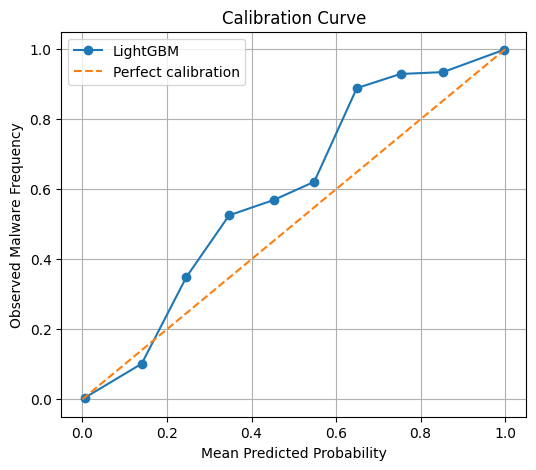

,Model,Log Loss,Brier Score
0,LightGBM,0.030565,0.008032


In [47]:
# ============================================================
# G. CALIBRATION ANALYSIS
# Calibration Curve + Log Loss + Brier Score
# ============================================================

import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    log_loss,
    brier_score_loss
)

# ------------------------------------------------------------
# Calibration curve
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(
    y_test,
    proba_clean,
    n_bins=10
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="LightGBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")

plt.ylabel("Observed Malware Frequency")

plt.title("Calibration Curve")

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Calibration metrics
# ------------------------------------------------------------

calibration_results = pd.DataFrame([{
    "Model": "LightGBM",

    "Log Loss": log_loss(
        y_test,
        proba_clean
    ),

    "Brier Score": brier_score_loss(
        y_test,
        proba_clean
    )
}])

calibration_results

In [49]:
# ============================================================
# SAVE ALL Q1 REVISION RESULTS + ZIP ARCHIVE
# KAGGLE SAFE VERSION
# ============================================================

import os
import shutil
import joblib
import pandas as pd

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = "/kaggle/working/maltrust_xai_q1_revision_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Saving results to:")
print(OUTPUT_DIR)

# ------------------------------------------------------------
# Save tables safely
# ------------------------------------------------------------

result_objects = {

    "clean_results.csv":
        "clean_results",

    "temporal_validation_results.csv":
        "temporal_results",

    "robustness_results.csv":
        "robustness_results",

    "external_validation_results.csv":
        "external_results",

    "deep_learning_baselines.csv":
        "deep_comparison",

    "mcnemar_results.csv":
        "mcnemar_results",

    "calibration_results.csv":
        "calibration_results"
}

# Optional objects
optional_objects = {
    "bootstrap_confidence_intervals.csv":
        "ci_results"
}

# ------------------------------------------------------------
# Save required results
# ------------------------------------------------------------

for filename, variable_name in result_objects.items():

    if variable_name in globals():

        obj = globals()[variable_name]

        if isinstance(obj, pd.DataFrame):

            save_path = os.path.join(
                OUTPUT_DIR,
                filename
            )

            obj.to_csv(
                save_path,
                index=False
            )

            print("Saved:", save_path)

    else:

        print(f"Skipped missing variable: {variable_name}")

# ------------------------------------------------------------
# Save optional results
# ------------------------------------------------------------

for filename, variable_name in optional_objects.items():

    if variable_name in globals():

        obj = globals()[variable_name]

        if isinstance(obj, pd.DataFrame):

            save_path = os.path.join(
                OUTPUT_DIR,
                filename
            )

            obj.to_csv(
                save_path,
                index=False
            )

            print("Saved:", save_path)

# ------------------------------------------------------------
# Save LightGBM model
# ------------------------------------------------------------

if "base_model" in globals():

    model_path = os.path.join(
        OUTPUT_DIR,
        "lightgbm_base_model.pkl"
    )

    joblib.dump(
        base_model,
        model_path
    )

    print("Saved model:", model_path)

else:

    print("base_model not found. Model not saved.")

# ------------------------------------------------------------
# Create ZIP archive
# ------------------------------------------------------------

zip_base = "/kaggle/working/maltrust_xai_q1_revision_results"

print("\nCreating ZIP archive...")

zip_file = shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir=OUTPUT_DIR
)

print("\nZIP archive created:")
print(zip_file)

# ------------------------------------------------------------
# Show saved files
# ------------------------------------------------------------

print("\nFiles inside output directory:")

for f in sorted(os.listdir(OUTPUT_DIR)):
    print("-", f)

Saving results to:
/kaggle/working/maltrust_xai_q1_revision_results
Saved: /kaggle/working/maltrust_xai_q1_revision_results/clean_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/temporal_validation_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/robustness_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/external_validation_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/deep_learning_baselines.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/mcnemar_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/calibration_results.csv
Saved: /kaggle/working/maltrust_xai_q1_revision_results/bootstrap_confidence_intervals.csv
Saved model: /kaggle/working/maltrust_xai_q1_revision_results/lightgbm_base_model.pkl

Creating ZIP archive...

ZIP archive created:
/kaggle/working/maltrust_xai_q1_revision_results.zip

Files inside output directory:
- bootstrap_confidence_intervals.csv
- calibration_res

In [50]:
# ============================================================
# FINAL SUMMARY TABLE FOR PAPER
# ============================================================

print("=== CLEAN RESULTS ===")
display(clean_results)

print("=== TEMPORAL VALIDATION ===")
display(temporal_results)

print("=== ROBUSTNESS RESULTS ===")
display(robustness_results)

print("=== EXTERNAL VALIDATION ===")
display(external_results)

print("=== DEEP LEARNING BASELINES ===")
display(deep_comparison)

print("=== CONFIDENCE INTERVALS ===")
display(ci_results)

print("=== MCNEMAR TEST ===")
display(mcnemar_results)

print("=== CALIBRATION RESULTS ===")
display(calibration_results)

=== CLEAN RESULTS ===


,Experiment,Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Clean random split,150000,797,0.989644,0.994186,0.985109,0.989626,0.999318


=== TEMPORAL VALIDATION ===


,Experiment,Train,Test,Train Samples,Test Samples,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Batch-level temporal validation,Older 70% dated EMBER files,Newer 30% dated EMBER files,22000,10000,780,0.9786,0.990046,0.966397,0.978078,0.99756


=== ROBUSTNESS RESULTS ===


...

,Metric,Mean,95% CI Lower,95% CI Upper
0,ROC-AUC,0.999322,0.999119,0.999487
1,F1-score,0.989664,0.988218,0.990935


=== MCNEMAR TEST ===


,Comparison,McNemar Statistic,p-value,LightGBM correct / MLP wrong,LightGBM wrong / MLP correct,Significant at 0.05
0,LightGBM vs MLP,9515.313142,0.0,9967,153,True


=== CALIBRATION RESULTS ===


,Model,Log Loss,Brier Score
0,LightGBM,0.030565,0.008032
